In [1]:
import pandas as pd 
import seaborn as sns
import numpy as np

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df = sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [4]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [5]:
df.drop(labels=["age","deck"],axis=1,inplace=True)

In [6]:
df.isnull().sum()

survived       0
pclass         0
sex            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

survived       0
pclass         0
sex            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

In [9]:
df.duplicated().sum()

375

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.duplicated().sum()

0

In [12]:
y=df['survived']
x=df.drop(labels="survived",axis=1)

In [13]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Index: 514 entries, 0 to 889
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   pclass       514 non-null    int64   
 1   sex          514 non-null    object  
 2   sibsp        514 non-null    int64   
 3   parch        514 non-null    int64   
 4   fare         514 non-null    float64 
 5   embarked     514 non-null    object  
 6   class        514 non-null    category
 7   who          514 non-null    object  
 8   adult_male   514 non-null    bool    
 9   embark_town  514 non-null    object  
 10  alive        514 non-null    object  
 11  alone        514 non-null    bool    
dtypes: bool(2), category(1), float64(1), int64(3), object(5)
memory usage: 41.8+ KB


In [14]:
x_num = x.select_dtypes(include=['int64','float64'])
x_num

,pclass,sibsp,parch,fare
0,3,1,0,7.2500
1,1,1,0,71.2833
2,3,0,0,7.9250
3,1,1,0,53.1000
4,3,0,0,8.0500
...,...,...,...,...
882,3,0,0,10.5167
885,3,0,5,29.1250
887,1,0,0,30.0000
888,3,1,2,23.4500


In [15]:
x_char = x.select_dtypes(exclude=['int64','float64'])
x_char

,sex,embarked,class,who,adult_male,embark_town,alive,alone
0,male,S,Third,man,True,Southampton,no,False
1,female,C,First,woman,False,Cherbourg,yes,False
2,female,S,Third,woman,False,Southampton,yes,True
3,female,S,First,woman,False,Southampton,yes,False
4,male,S,Third,man,True,Southampton,no,True
...,...,...,...,...,...,...,...,...
882,female,S,Third,woman,False,Southampton,no,True
885,female,Q,Third,woman,False,Queenstown,no,False
887,female,S,First,woman,False,Southampton,yes,True
888,female,S,Third,woman,False,Southampton,no,False


In [16]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [17]:
for col in x_char.columns:
    x_char[col] = le.fit_transform(x_char[col])
x_char.head()

,sex,embarked,class,who,adult_male,embark_town,alive,alone
0,1,2,2,1,1,2,0,0
1,0,0,0,2,0,0,1,0
2,0,2,2,2,0,2,1,1
3,0,2,0,2,0,2,1,0
4,1,2,2,1,1,2,0,1


In [18]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [19]:
x_num = pd.DataFrame(sc.fit_transform(x_num),
                    columns = x_num.columns,
                    index = x_num.index)
x_num.head()

,pclass,sibsp,parch,fare
0,0.936377,0.409639,-0.581256,-0.584518
1,-1.302217,0.409639,-0.581256,0.496726
2,0.936377,-0.617456,-0.581256,-0.573120
3,-1.302217,0.409639,-0.581256,0.189689
4,0.936377,-0.617456,-0.581256,-0.571010


In [20]:
data = pd.concat([x_char,x_num],axis = 1)
data.head()

,sex,embarked,class,who,adult_male,embark_town,alive,alone,pclass,sibsp,parch,fare
0,1,2,2,1,1,2,0,0,0.936377,0.409639,-0.581256,-0.584518
1,0,0,0,2,0,0,1,0,-1.302217,0.409639,-0.581256,0.496726
2,0,2,2,2,0,2,1,1,0.936377,-0.617456,-0.581256,-0.573120
3,0,2,0,2,0,2,1,0,-1.302217,0.409639,-0.581256,0.189689
4,1,2,2,1,1,2,0,1,0.936377,-0.617456,-0.581256,-0.571010


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(data,y,train_size=0.7,
                                                random_state=6)

In [22]:
print(df.shape)
print(x_train.shape)
print(x_test.shape)

(514, 13)
(359, 12)
(155, 12)


In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

In [24]:
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [25]:
ypred = knn.predict(x_test)
ypred

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1,
       0], dtype=int64)

In [26]:
## Model evaluation
## hyperparameter tuning 
## serialization and de-serialization

In [27]:
## knn or sleepy algorithm - mostly not used because based on nearest value it will select and used on null values 
## randomly will select k value
## 100 points
## from every point to predict point will calculate distance
## euclidean distance = sqrt(y-yi)^2
## minkowiski and manhatton
## will selecting nearest points ( k value)
## classification - majority voting 
## regression - mean or median

In [28]:
## model evaluation
## accuracy - correct predictions / total values
## confusion matrix
## precision recall f1 score


In [29]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,ypred))

0.8774193548387097


In [30]:
from sklearn.metrics import confusion_matrix
conn = confusion_matrix(y_test,ypred)
conn

array([[69,  9],
       [10, 67]], dtype=int64)

<Axes: >

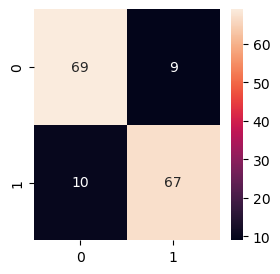

In [31]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
conn = confusion_matrix(y_test,ypred)
plt.figure(figsize = [3,3])
sns.heatmap(conn,annot=True)

In [32]:
## hyperparameter tuning
params = {"n_neighbors":[3,5,7,9,11]}

In [33]:
## gridsearchcv and randomsearchcv
from sklearn.model_selection import GridSearchCV
clf = GridSearchCV(estimator=knn,
                  param_grid=params,
                  cv=5,scoring="accuracy")

In [34]:
clf.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [3, 5, 7, 9, 11]}, scoring='accuracy')

In [35]:
clf.best_params_

{'n_neighbors': 3}

In [36]:
clf.best_score_

0.9221048513302034

In [38]:
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train,y_train)
ypred=knn.predict(x_test)
print(accuracy_score(y_test,ypred))

0.8774193548387097


## Logistic Regression

In [39]:
### Logistic Regression : best separation line - max likelihood
## probability : no of success/total outcomes
## likelihood : chance of getting prob
## Linear - best fit line - min loss function
## goal : best separation line - max likelihood

## study hrs p/f pred-p/f
## 2 hrs      0      1
## 5          1      1
## 7          1      1
# y= mx+c
# randomly take m and c m=3 and c=2
# y1=3*2+2 = 8
# similarly y2= 17 and y3 = 23 
## since y1 y2 and y3 are continuous values so classification is not applicable 
## to apply classification we use sigmoid to convert linear data into non linear data means 0s and 1s
## sigmoid - only two points [0,1] and points less than 0.5 are 0 and greater than 0.5 are 1
## sigmoid 1 = 1/1+e^-8 = 1 = 1(classified)
## sigmoid 2 = 1/1+e^-23 = 1 = 1(classified)
## sigmoid 3 = 1/1+e^-17 = 1 = 1(classified)
## max likelihood = yilog(yi)* (1-yi)log(1-yi)
## max likelihood = yactlog(yact)* (1-ypred)log(1-ypred)
## example : 50% correct prediction 
## with the help of gradient descent we will be changing the m and c value
## with the best m and c value -> we will getting the max likelihood
## Algorithm will be stopped after getting the best separation line 

In [40]:
from sklearn.linear_model import LogisticRegression
log = LogisticRegression()

In [41]:
log.fit(x_train,y_train)

LogisticRegression()

In [43]:
ypred = log.predict(x_test)
ypred

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1], dtype=int64)

1.0


<Axes: >

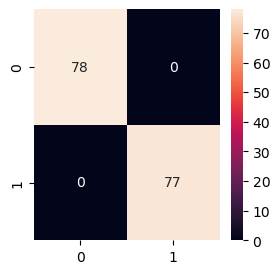

In [44]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(accuracy_score(y_test,ypred))
plt.figure(figsize=[3,3])
sns.heatmap(confusion_matrix(y_test,ypred),annot=True)

In [45]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()

In [46]:
rf.fit(x_train,y_train)

RandomForestClassifier()

In [47]:
ypred = rf.predict(x_test)
ypred

array([0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       1], dtype=int64)

1.0


<Axes: >

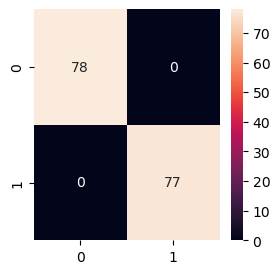

In [48]:
from sklearn.metrics import accuracy_score,confusion_matrix
print(accuracy_score(y_test,ypred))
plt.figure(figsize=[3,3])
sns.heatmap(confusion_matrix(y_test,ypred),annot=True)

In [57]:
## we use serialization and de serialization to convert model into a file - we use pickle library
## dump - model to file
## load - file to model
## wb means write binary 
## rb means read binary
## machine learning file will be stored with extension pkl
import pickle
with open("titanic_rf.pkl","wb") as file:
    pickle.dump(rf,file)